**IFSP Campinas** <br/>
**CMPINAM: Introdução ao Aprendizado de Máquina (2025.1)** <br/>

---

<center>

**Prof: Everton Meyer da Silva**

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.
</center>

---

# <font color='#0C509E' style='font-size: 40px;'>KNN from Scratch</font>

Neste tutorial, você vai aprender sobre o algoritmo kNN, incluindo como ele funciona e como implementá-lo do zero (sem usar bibliotecas).

O algoritmo k-Nearest Neighbors (k-NN) é um método de aprendizado de máquina supervisionado usado para classificação e regressão. Ele funciona encontrando os k exemplos mais próximos (vizinhos) de um novo ponto de dados no espaço multidimensional. Na classificação, a classe predominante entre os vizinhos é atribuída ao novo ponto, enquanto na regressão, a média ou a mediana dos valores alvo dos vizinhos é usada como a previsão. O valor de k, que representa o número de vizinhos a serem considerados, é um hiperparâmetro que pode afetar o desempenho do modelo. O k-NN é simples de entender e implementar, mas pode ser sensível à escala dos recursos e à escolha de k.

Após concluir este tutorial, você saberá:

- Como codificar o algoritmo KNN.
- Como avaliar o desempenho do KNN em um conjunto de dados real (Iris dataset).
- Como usar o algoritmo KNN para fazer previsões para novos dados.

## Bibliotecas necessárias

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

## Etapas do KNN

*   Calcular a distância euclidiana
*   Obter k vizinhos mais próximos
*   Realizar as predições

Estes passos vão ensinar a você os fundamentos para implementar e aplicar o algoritmo dos KNN para problemas de modelagem preditiva de classificação e regressão.

### Calcular a distância euclidiana

In [3]:
# Base de dados para testar a função
df_grades = pd.read_csv('/content/students_grade.csv')

In [4]:
df_grades.head()

,mean_grade,weekly_study_hours,approved
0,9.196898,3.173381,1
1,9.136081,11.195896,1
2,7.936936,5.603348,1
3,2.682825,4.167854,1
4,7.383286,7.832201,1


In [5]:
df_grades.shape

(31, 3)

<Axes: >

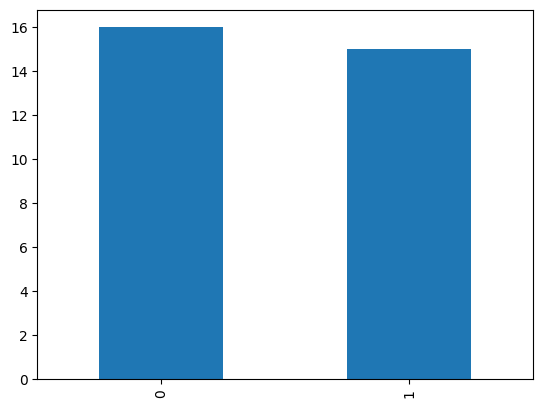

In [ ]:
df_grades['approved'].value_counts().plot(kind='bar')

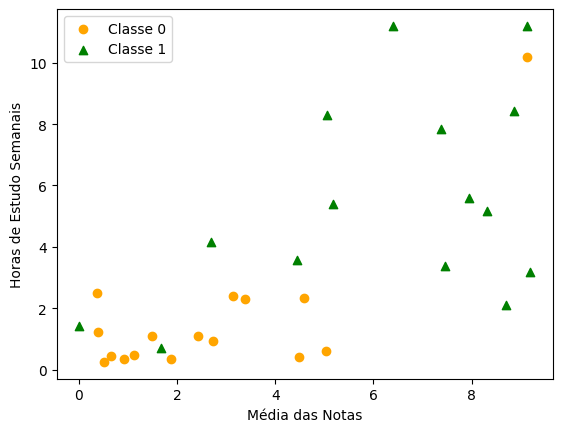

In [6]:
# Separe os dados em dois DataFrames com base na classe
df_class_0 = df_grades[df_grades['approved'] == 0]
df_class_1 = df_grades[df_grades['approved'] == 1]

# Crie o scatterplot com marcadores diferentes
plt.scatter(df_class_0['mean_grade'], df_class_0['weekly_study_hours'], c='orange', marker='o', label='Classe 0')
plt.scatter(df_class_1['mean_grade'], df_class_1['weekly_study_hours'], c='green', marker='^', label='Classe 1')

# Adicione rótulos aos eixos
plt.xlabel('Média das Notas')
plt.ylabel('Horas de Estudo Semanais')

# Adicione uma legenda
plt.legend()

# Exiba o gráfico
plt.show()

In [7]:
# Função para calcular a distância euclidiana entre duas instâncias (vetores)
def euclidean_distance(inst1, inst2):
  distance = 0.0
  for i in range(len(inst1)-1):
    distance += (inst1[i] - inst2[i])**2
  return sqrt(distance)

In [8]:
df_grades.head(3)

,mean_grade,weekly_study_hours,approved
0,9.196898,3.173381,1
1,9.136081,11.195896,1
2,7.936936,5.603348,1


In [9]:
inst1 = df_grades.iloc[0,:].values
inst1

array([9.19689791, 3.17338094, 1.        ])

In [10]:
inst2 = df_grades.iloc[2,:].values
inst2

array([7.9369359 , 5.60334776, 1.        ])

In [12]:
inst3 = df_grades.iloc[3,:].values
inst3

array([2.68282464, 4.16785407, 1.        ])

In [16]:
print(euclidean_distance(inst1, inst3))

6.589546828869426


In [17]:
print(euclidean_distance(inst2, inst3))

5.446680393510259


In [18]:
sqrt((9.19689791 - 7.9369359)**2 + (3.17338094-5.60334776)**2)

2.7371961955519657

In [19]:
# Testar a função
for inst in df_grades.iloc[:10,:-1].values:
  distance = euclidean_distance(inst1, inst)
  print("Distance: ", distance)

Distance:  0.0
Distance:  8.022745426343578
Distance:  2.737196194422338
Distance:  6.589546828869426
Distance:  4.999379284358284
Distance:  1.1818688915382178
Distance:  4.762362646073785
Distance:  9.351538097974712
Distance:  6.573852121358726
Distance:  5.2816938634065504


### Obter k vizinhos mais próximos

In [38]:
# Localizar os k vizinhos mais próximos
def get_neighbors(train, test_row, k):

    # Inicializa uma lista para armazenar as distâncias e instâncias de treinamento correspondentes.
    distances = list()

    # Loop para calcular as distâncias entre a instância de teste e todas as instâncias de treinamento.
    for train_row in train:
        # Calcula a distância euclidiana entre a instância de teste e a instância de treinamento atual.
        dist = euclidean_distance(train_row, test_row)

        # Adiciona a instância de treinamento e sua distância à lista de distâncias.
        distances.append((train_row, dist))

    # Ordena a lista de distâncias com base nas distâncias em ordem crescente.
    distances.sort(key=lambda tup: tup[1])

    # Inicializa uma lista para armazenar os k vizinhos mais próximos.
    neighbors = list()

    # Loop para selecionar os k vizinhos mais próximos a partir da lista ordenada de distâncias.
    for i in range(k):
        # Adiciona a instância de treinamento correspondente ao i-ésimo vizinho mais próximo.
        neighbors.append(distances[i][0])

    # Retorna a lista de k vizinhos mais próximos.
    return neighbors

In [39]:
test_row = [4.0, 5.5, 0]
neighbors = get_neighbors(df_grades.values, test_row, 3)

In [40]:
df_grades.head()

,mean_grade,weekly_study_hours,approved
0,9.196898,3.173381,1
1,9.136081,11.195896,1
2,7.936936,5.603348,1
3,2.682825,4.167854,1
4,7.383286,7.832201,1


In [41]:
neighbors

[array([5.18537222, 5.38340049, 1.        ]),
 array([2.68282464, 4.16785407, 1.        ]),
 array([4.45191933, 3.57992269, 1.        ])]

In [42]:
[row[-1] for row in neighbors]

[1.0, 1.0, 1.0]

### Realizar as predições

In [43]:
# Função para realizar a previsão
def predict_classification(train, test_row, k):

    # Obtém os k vizinhos mais próximos da instância de teste usando a função get_neighbors.
    neighbors = get_neighbors(train, test_row, k)

    # Extrai os valores de saída das instâncias vizinhas (última coluna, que representa a classe).
    output_values = [row[-1] for row in neighbors]

    # Realiza a classificação prevendo a classe com base na classe mais frequente entre os vizinhos.
    prediction = max(set(output_values), key=output_values.count)

    # Retorna a classe prevista.
    return prediction

In [51]:
test_inst = [4.0, 3.0]
prediction = predict_classification(df_grades.values, test_inst, 3)
print(prediction)

0.0


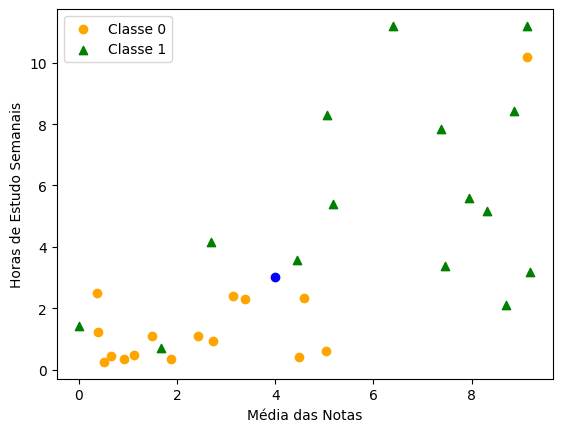

In [52]:
# Crie o scatterplot com marcadores diferentes
plt.scatter(df_class_0['mean_grade'], df_class_0['weekly_study_hours'], c='orange', marker='o', label='Classe 0')
plt.scatter(df_class_1['mean_grade'], df_class_1['weekly_study_hours'], c='green', marker='^', label='Classe 1')
plt.scatter(x=test_inst[0], y=test_inst[1], c='blue', marker='o')

# Adicione rótulos aos eixos
plt.xlabel('Média das Notas')
plt.ylabel('Horas de Estudo Semanais')

# Adicione uma legenda
plt.legend()

# Exiba o gráfico
plt.show()

## Caso de estudo - Iris dataset

**Atividade:** Aplicando o Algoritmo k-Nearest Neighbors (KNN) ao Conjunto de Dados das Flores Iris

---
</br>

**Objetivo:** Nesta atividade, vocês aprenderão a aplicar o algoritmo KNN ao conjunto de dados Iris, uma tarefa comum em aprendizado de máquina. Vocês também irão praticar técnicas de pré-processamento de dados e validação cruzada. </br></br>

**Etapas da Atividade**
</br>

**Carregando e Preparando os Dados**

- Carregar a base de dados
- Verificar os tipos de dados e converter as colunas para números (floats e inteiros) caso necessário
</br></br>

**Dividindo os Dados**
- Dividir os dados em conjuntos de treinamento e teste
- Vocês devem entender a importância de dividir os dados e discutir os parâmetros de divisão (por exemplo, tamanho dos folds).
</br></br>

**Validação Cruzada**

- Utilizar a validação cruzada k-fold com 5 folds para avaliar o desempenho do algoritmo KNN.
- Avaliar a precisão das previsões usando a acurácia como métrica.
</br></br>

**Discussão e Análise**

- Vocês devem discutir os resultados obtidos, incluindo a precisão média do algoritmo KNN.
- Explorar como a escolha do valor de k afeta o desempenho do algoritmo.
</br></br>

**Avaliação**

Os alunos serão avaliados com base na precisão de suas previsões, compreensão do algoritmo KNN e habilidade de discutir resultados.

`Esta atividade oferece aos alunos a oportunidade de aplicar conceitos de aprendizado de máquina em um contexto prático e familiariza-os com as etapas típicas de pré-processamento de dados, modelagem e avaliação de algoritmos. Além disso, incentiva a exploração e experimentação para aprimorar suas habilidades em aprendizado de máquina.`

---

**Observação** </br>
<font color='#d3643c' style='font-size: 40px;'>Faça as alterações necessárias nos códigos anteriores para realizar a atividade.</font>

### Iris Flower Species Dataset

 A base de dados "Iris" é uma base de dados simples, mas amplamente utilizada no campo da Ciência de Dados e Aprendizado de Máquina.

O conjunto envolve a previsão da espécie da flor com base em medições das flores iris. É um problema de classificação multiclasse. Existem 150 observações com 4 variáveis de entrada e 1 variável de saída. Os nomes das variáveis são os seguintes:

*   Sepal length in cm.
*   Sepal width in cm.
*   Petal length in cm.
*   Petal width in cm.
*   Class

In [ ]:
# Carregando a base de dados Iris
df_iris = pd.read_csv('https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv')

In [ ]:
df_iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [ ]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df_iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Selecionando somente os atributos preditivos
X = df_iris.iloc[:,:-1]

# Selecionando somente os valores de target
y = df_iris['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

In [ ]:
X_train.shape

(105, 4)

In [ ]:
X_test.shape

(45, 4)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=20, p=1)

In [ ]:
knn_model.fit(X=X_train, y=y_train)

KNeighborsClassifier(n_neighbors=20, p=1)

In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
X_test.head()

,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4


In [ ]:
y_test.values

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'setosa', 'setosa',
       'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor',
       'setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'versicolor', 'setosa', 'setosa'], dtype=object)

In [ ]:
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'setosa', 'setosa',
       'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor',
       'setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'versicolor', 'setosa', 'setosa'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

1.0